In [ ]:
# --- project bootstrap ---
import os
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
os.chdir(ROOT)
# -------------------------


In [64]:
import numpy as np
import matplotlib.pyplot as plt

path = "cache/G_history_samples/N16x16/N16x16_C20_S100_nshNone_DW1_init-default_n_a0.5_markov_circuit.npz"
data = np.load(path)
G_hist = data[data.files[0]]                   # shape (S, T, Nlayer, Nlayer)
                # final-cycle top-layer covariances
 
 

In [ ]:
S, T, Ntot, _ = G_hist.shape
Nlayer = Ntot//2
G_final = G_hist[:, -1, :Nlayer, :Nlayer]  # shape (Nlayer, Nlayer)
print(G_final.shape)
Nx = Ny = 16


(100, 512, 512)


In [60]:
def as_block(G_flat, Nx, Ny):
    """(Nlayer,Nlayer)->(Nx,Ny,2,Nx,Ny,2), respecting Fortran ordering."""
    G2 = 0.5 * (G_flat + np.eye(G_flat.shape[-1], dtype=np.complex128))
    G6 = G2.reshape(2, Nx, Ny, 2, Nx, Ny, order="F")
    return np.transpose(G6, (1, 2, 0, 4, 5, 3))

def current_maps_gauge_invariant(G_flat, Nx, Ny):
    """
    Gauge-invariant currents extracted from a two-point tensor block:
      block[x, y, μ, x', y', μ′] = ⟨c†_{x,y,μ} c_{x',y',μ′}⟩

    Returns
    -------
    J_x, J_y : arrays of shape (Nx, Ny)
        Gauge-invariant currents flowing along +x and +y bonds.
    """
    block = as_block(G_flat, Nx, Ny)
    x_idx = np.arange(Nx)[:, None]
    y_idx = np.arange(Ny)[None, :]

    x_next = (x_idx + 1) % Nx
    y_next = (y_idx + 1) % Ny

    G11_x = block[x_idx, y_idx, 0, x_next, y_idx, 0]
    G22_x = block[x_idx, y_idx, 1, x_next, y_idx, 1]
    G12_x = block[x_idx, y_idx, 0, x_next, y_idx, 1]

    G11_y = block[x_idx, y_idx, 0, x_idx, y_next, 0]
    G22_y = block[x_idx, y_idx, 1, x_idx, y_next, 1]
    G12_y = block[x_idx, y_idx, 0, x_idx, y_next, 1]

    J_x = np.imag(-G11_x + G22_x + 1j * G12_x)
    J_y = np.imag(-G11_y + G22_y - G12_y)
    return J_x, J_y


J_x, J_y = current_maps_gauge_invariant(G_final, Nx, Ny)

<function matplotlib.pyplot.show(close=None, block=None)>

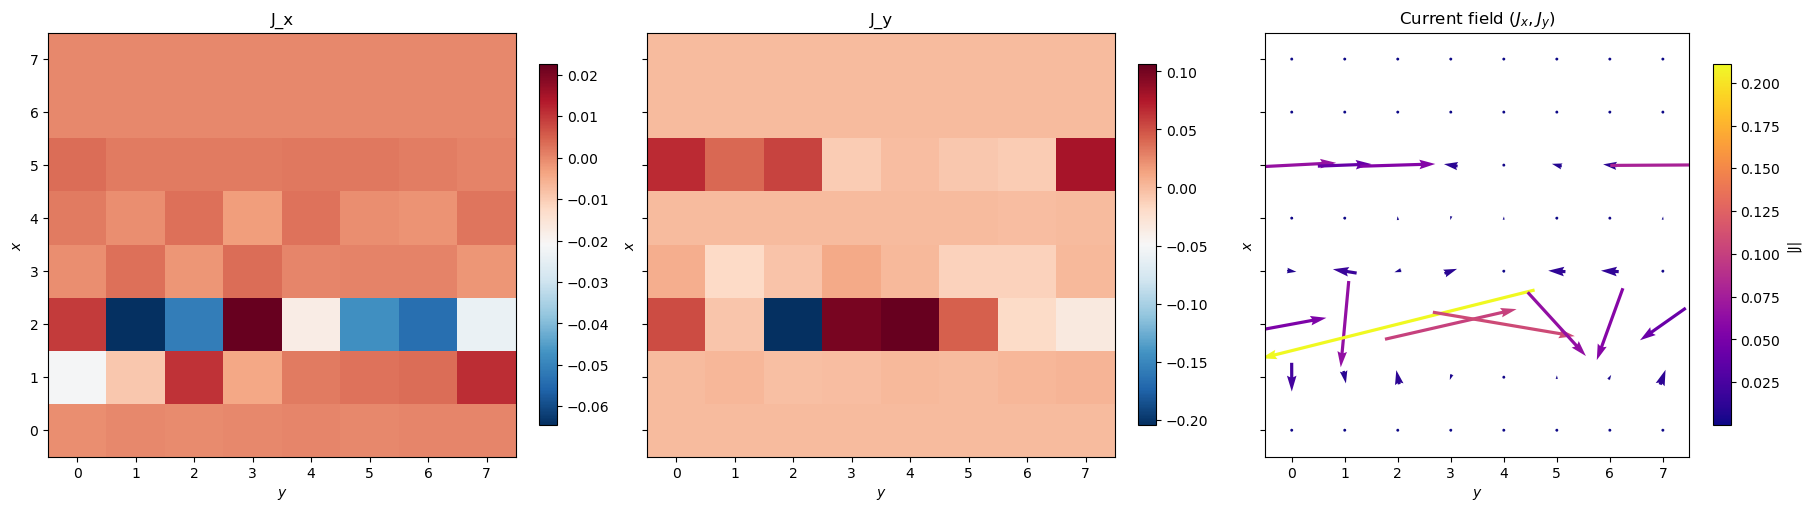

In [61]:
# --- currents and plots ---
extent = (-0.5, J_x.shape[1] - 0.5, -0.5, J_x.shape[0] - 0.5)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True, constrained_layout=True)

for ax, (title, data) in zip(axes[:2], [("J_x", J_x), ("J_y", J_y)]):
    im = ax.imshow(
        data,
        origin="lower",
        aspect="auto",
        cmap="RdBu_r",
        extent=extent,
    )
    ax.set_title(title)
    ax.set_xlabel(r"$y$")
    ax.set_ylabel(r"$x$")
    fig.colorbar(im, ax=ax, shrink=0.85)

y_coords, x_coords = np.meshgrid(np.arange(Ny), np.arange(Nx))
magnitude = np.hypot(J_x, J_y)
quiv = axes[2].quiver(
    y_coords,
    x_coords,
    J_y,
    J_x,
    magnitude,
    cmap="plasma",
    angles="xy",
    scale_units="xy",
    scale=None,
    pivot="mid",
)
axes[2].set_xlim(extent[0], extent[1])
axes[2].set_ylim(extent[2], extent[3])
axes[2].set_xlabel(r"$y$")
axes[2].set_ylabel(r"$x$")
axes[2].set_title("Current field $(J_x, J_y)$")
axes[2].set_aspect("equal")
fig.colorbar(quiv, ax=axes[2], shrink=0.85, label="|J|")

plt.show

DWs at x=(2, 5)
------------------------- classA_U1FGTN Initialized -------------------------


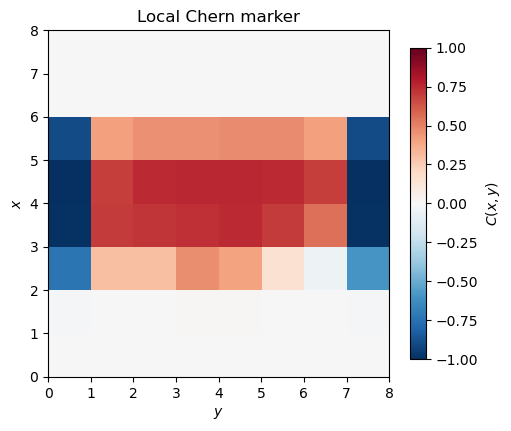

In [62]:
import importlib
import fgtn.classA_U1FGTN as mod
importlib.reload(mod)
from fgtn.classA_U1FGTN import classA_U1FGTN
model = classA_U1FGTN(Nx=Nx, Ny=Ny, DW=True, alpha_triv = 30)

chern_map = model.local_chern_marker_flat(G_final)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(
    chern_map,
    origin="lower",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    extent=[0, Ny, 0, Nx],
    aspect="auto",
)
ax.set_xlabel("$y$")
ax.set_ylabel("$x$")
ax.set_title("Local Chern marker")
cbar = fig.colorbar(im, ax=ax, shrink=0.9)
cbar.set_label("$C(x,y)$")
plt.show()


In [67]:
model.plot_corr_y_profiles(G_hist)

ValueError: entanglement_contour_suite expects last dims 256 or 128; got 512

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from fgtn.classA_U1FGTN import classA_U1FGTN
# --- model ---
Nx = Ny = 8
model = classA_U1FGTN(Nx=Nx, Ny=Ny, DW=True, alpha_triv=30, alpha_top=4)

# --- run adaptive circuit with many samples (top-layer histories) ---
res = model.run_adaptive_circuit(
    cycles=20,
    G_history=True,
    store="top",              # top-layer blocks (2*Nx*Ny x 2*Nx*Ny)
    samples=100,
    parallelize_samples=True, # set n_jobs=<cores> if desired
    n_jobs=None,
    progress=False,
    init_mode="default",
    remember_init=True,
    save=True,
    save_suffix="_demo",
)
G_hist = res["G_hist"]           # (S, T, dim, dim)
G_avg_hist = G_hist.mean(axis=0) # (T, dim, dim) sample-averaged

print("Saved history to:", res["save_path"])
print("G_hist shape:", G_hist.shape, "| G_avg_hist shape:", G_avg_hist.shape)


DWs at x=(2, 5)
------------------------- classA_U1FGTN Initialized -------------------------
[info] Adaptive circuit will save history to cache/G_history_samples/N8x8_C20_S100_nshNone_DW1_atriv30_atop4_init-default_store-top_demo.npz


samples:   0%|          | 0/100 [1:30:15<?, ?task/s]


Saved history to: cache/G_history_samples/N8x8_C20_S100_nshNone_DW1_atriv30_atop4_init-default_store-top_demo.npz
G_hist shape: (100, 21, 128, 128) | G_avg_hist shape: (21, 128, 128)


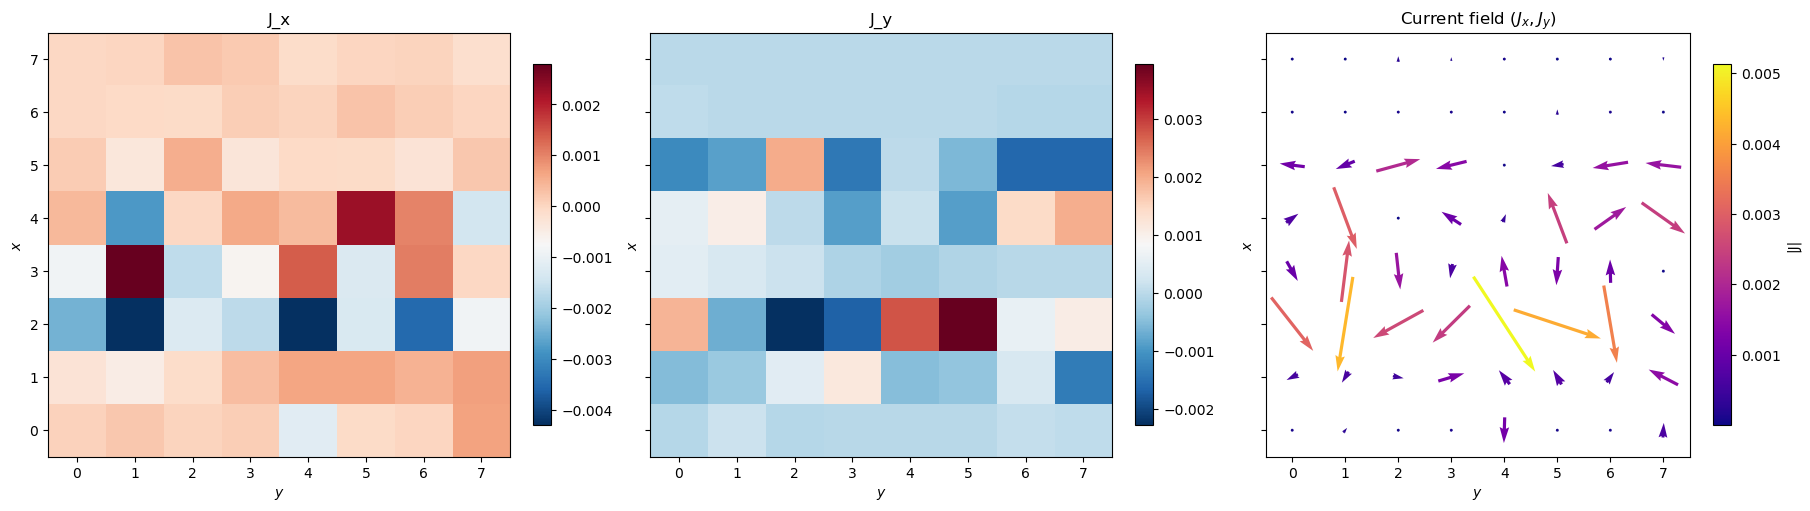

In [2]:

# --- steady-state currents from the averaged final covariance ---
G_final_avg = G_avg_hist[-1]
Jx, Jy = model.current_maps_gauge_invariant(G_final_avg)
model.plot_current_maps(Jx, Jy)
plt.show()


In [3]:

# --- entanglement contour dynamics from the averaged history ---
contours = np.array([model.entanglement_contour(G_avg_hist[t]) for t in range(G_avg_hist.shape[0])])
vmax = float(np.max(contours)) or 1.0

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(contours[0], origin="lower", cmap="Blues", vmin=0, vmax=vmax)
ax.set_xlabel("y"); ax.set_ylabel("x")
title = ax.set_title("Entanglement contour (avg) t=0")
fig.colorbar(im, ax=ax, shrink=0.8)

def update(frame):
    im.set_data(contours[frame])
    title.set_text(f"Entanglement contour (avg) t={frame}")
    return im, title

anim = FuncAnimation(fig, update, frames=contours.shape[0], interval=400, blit=False)
plt.close(fig)
HTML(anim.to_jshtml())
